当然。TF-IDF 是信息检索和文本挖掘中非常经典的技术。我们先分解概念，再用一个具体例子说明。

**TF-IDF 的全称**：  
**T**erm **F**requency – **I**nverse **D**ocument **F**requency  
中文常称为“词频-逆文档频率”。

---

## 1. 直观理解：它要解决什么问题？

在一篇文章中，想找出**对这篇文章最重要**的几个词。

- 如果一个词在**这篇文章里出现很多次**，它可能是重要的（比如标题中的词）。  
  → 这叫做 **TF（词频）**。

- 但像“的”、“是”、“在”这种词，几乎每篇文章都有很多次，它们不算重要。  
  → 所以需要**惩罚这些常见词**，用 **IDF（逆文档频率）**。

- 如果一个词在很多文章中都出现 → 它的区分能力弱 → IDF 值低。  
- 如果一个词只在少数文章中出现 → 它的区分能力强 → IDF 值高。

TF-IDF = TF × IDF  
→ 得分越高，这个词对**当前文档**越有代表性。

---

## 2. 公式（常用版本）

**TF (词频)**：  
$TF(t, d) = \frac{\text{词 } t \text{ 在文档 } d \text{ 中出现的次数}}{\text{文档 } d \text{ 的总词数}}$
（也有直接用原始次数或对数形式的）

**IDF (逆文档频率)**：  
$
IDF(t) = \log \left( \frac{\text{总文档数 } N}{\text{包含词 } t \text{ 的文档数 } + 1} \right)$
（+1 是为了防止分母为 0；log 通常以 10 或 e 为底）

**TF-IDF**：  
$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$

---

## 3. 具体例子（帮你手算一次）

假设有 3 篇短文（N=3）：

- 文档1：`苹果 好吃`
- 文档2：`苹果 香蕉 好吃`
- 文档3：`苹果 苹果 苹果`

**词“好吃”**：
- 文档1 出现 1 次，总词数 2 → TF = 1/2 = 0.5  
- 文档2 出现 1 次，总词数 3 → TF = 1/3 ≈ 0.333  
- 文档3 出现 0 次 → TF = 0  

包含“好吃”的文档数 = 2（文档1和文档2）  
$IDF = \log\left( \frac{3}{2} \right) \approx \log(1.5) \approx 0.176$


**词“苹果”**：
- 文档1 TF = 1/2 = 0.5  
- 文档2 TF = 1/3 ≈ 0.333  
- 文档3 TF = 3/3 = 1  

包含“苹果”的文档数 = 3  
$IDF = \log\left( \frac{3}{3} \right) = \log(1) = 0$

**结果**：
- “好吃”在文档1的 TF-IDF = 0.5 × 0.176 ≈ **0.088**  
- “苹果”在文档1的 TF-IDF = 0.5 × 0 = **0**

→ 在这个集合中，“苹果”在所有文档都出现，IDF=0，因此即使文档3里“苹果”出现很多次，TF-IDF 依然是 0。  
→ “好吃”只出现在部分文档，有一定区分度。

（实际上常用做法会平滑 IDF，防止重要词在全部文档时得分为 0，但我们先理解这个核心逻辑。）

---

## 4. TF-IDF 的作用

- **文本关键词提取**（给文档自动打标签）  
- **搜索引擎的文档排序**（早期基础方法之一）  
- **文本相似度计算**（把 TF-IDF 作为特征向量）  
- **分类/聚类前的特征表示**

---

## 5. 局限与后续改进

- 没有考虑**语义**（同义词、上下文）。  
- 对长文档偏向明显（可做归一化）。  
- IDF 基于统计，无法捕捉词序。  
→ 后来出现 **BM25**、**Word2Vec + TF-IDF**、**BERT** 等更先进方法。

---

**一句话总结**：  
> TF-IDF 用一个词的**本篇文章频率**乘以**全体文章中的罕见程度**，来找出对某篇文章最具代表性的词。

In [6]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

import platform

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

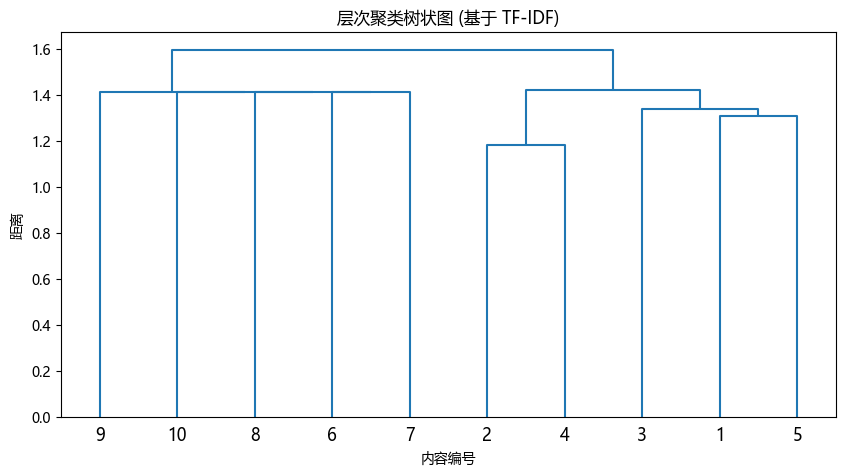


=== 聚类结果 (KMeans, k=3) ===


【类别 1】
  - 民生直通车丨一季度新增就业299万人 下一步稳就业有实招
  - 经济大省“闯新路”，书写“不一样”的担当
  - 新疆首个离网绿电直连制氢项目获批
  - “五一”铁路运输启动 预计发送旅客1.58亿人次

【类别 2】
  - 市委常委会传达总书记重要指示精神，研究“十五五”规划纲要目标任务分工、开发区高质量发展等
  - 聚焦体育发展，广东 “十五五”《规划纲要》这样部署
  - 广西“十五五”规划印发 锚定GDP年均增长5%左右目标
  - 河北“十五五”规划纲要：明确利用存量房源等方式满足住房保障需求
  - “十五五”重点培育三类数字产业集群

【类别 3】
  - 科技为翼 文化为魂 中外城市共探高质量发展之路


In [7]:
# 你的数据
data = [
"市委常委会传达总书记重要指示精神，研究“十五五”规划纲要目标任务分工、开发区高质量发展等",
"聚焦体育发展，广东 “十五五”《规划纲要》这样部署",
"广西“十五五”规划印发 锚定GDP年均增长5%左右目标",
"河北“十五五”规划纲要：明确利用存量房源等方式满足住房保障需求",
"“十五五”重点培育三类数字产业集群",
"民生直通车丨一季度新增就业299万人 下一步稳就业有实招",
"经济大省“闯新路”，书写“不一样”的担当",
"科技为翼 文化为魂 中外城市共探高质量发展之路",
"新疆首个离网绿电直连制氢项目获批",
"“五一”铁路运输启动 预计发送旅客1.58亿人次",
]

# 1. 计算 TF-IDF 特征
vectorizer = TfidfVectorizer(stop_words=None, token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = vectorizer.fit_transform(data)

# 2. 余弦相似度矩阵
similarity_matrix = cosine_similarity(tfidf_matrix)

# 3. 层次聚类并画树状图（方便观察分几类）
linkage_matrix = linkage(tfidf_matrix.toarray(), method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=range(1, 11))
plt.title("层次聚类树状图 (基于 TF-IDF)")
plt.xlabel("内容编号")
plt.ylabel("距离")
plt.show()

# 4. 手动选择 3 类（可调整，看树状图切分位置）
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(tfidf_matrix.toarray())

# 5. 结果展示
df_result = pd.DataFrame({
    "内容": data,
    "聚类类别": labels
})

print("\n=== 聚类结果 (KMeans, k=3) ===\n")
for c in range(n_clusters):
    print(f"\n【类别 {c+1}】")
    for idx, row in df_result[df_result["聚类类别"] == c].iterrows():
        print(f"  - {row['内容']}")

=== 轮廓系数评估（K-Medoids）===
k=2, 轮廓系数=0.034
k=3, 轮廓系数=0.046
k=4, 轮廓系数=0.045
k=5, 轮廓系数=0.022

✅ 选择最佳 k=3 (轮廓系数最高)

K-Medoids 聚类结果（k=3）

【类别 1】
  📍 聚类中心：广西“十五五”规划印发 锚定GDP年均增长5%左右目标
  📋 成员（共5条）：
    - 广西“十五五”规划印发 锚定GDP年均增长5%左右目标 👑
    - 民生直通车丨一季度新增就业299万人 下一步稳就业有实招
    - 经济大省“闯新路”，书写“不一样”的担当
    - 科技为翼 文化为魂 中外城市共探高质量发展之路
    - “五一”铁路运输启动 预计发送旅客1.58亿人次

【类别 2】
  📍 聚类中心：新疆首个离网绿电直连制氢项目获批
  📋 成员（共1条）：
    - 新疆首个离网绿电直连制氢项目获批 👑

【类别 3】
  📍 聚类中心：河北“十五五”规划纲要：明确利用存量房源等方式满足住房保障需求
  📋 成员（共4条）：
    - 市委常委会传达总书记重要指示精神，研究“十五五”规划纲要目标任务分工、开发区高质量发展等
    - 聚焦体育发展，广东 “十五五”《规划纲要》这样部署
    - 河北“十五五”规划纲要：明确利用存量房源等方式满足住房保障需求 👑
    - “十五五”重点培育三类数字产业集群

聚类质量评估
Davies-Bouldin Index: 1.820 (越小越好)
Calinski-Harabasz Index: 1.183 (越大越好)


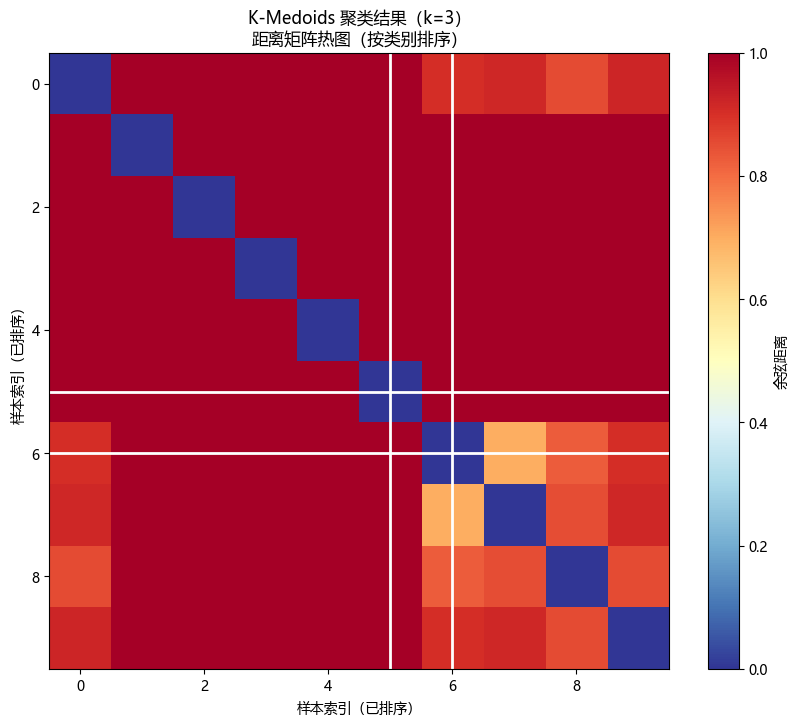


每个聚类的代表性关键词（基于 TF-IDF）

【类别 1】
    民生直通车丨一季度新增就业299万人: 0.141
    下一步稳就业有实招: 0.141
    科技为翼: 0.115
    文化为魂: 0.115
    中外城市共探高质量发展之路: 0.115

【类别 2】
    新疆首个离网绿电直连制氢项目获批: 1.000
    闯新路: 0.000
    预计发送旅客1: 0.000
    铁路运输启动: 0.000
    重点培育三类数字产业集群: 0.000

【类别 3】
    十五五: 0.357
    规划纲要: 0.226
    重点培育三类数字产业集群: 0.215
    明确利用存量房源等方式满足住房保障需求: 0.143
    河北: 0.143


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import silhouette_score
import random

# 你的数据
data = [
"市委常委会传达总书记重要指示精神，研究“十五五”规划纲要目标任务分工、开发区高质量发展等",
"聚焦体育发展，广东 “十五五”《规划纲要》这样部署",
"广西“十五五”规划印发 锚定GDP年均增长5%左右目标",
"河北“十五五”规划纲要：明确利用存量房源等方式满足住房保障需求",
"“十五五”重点培育三类数字产业集群",
"民生直通车丨一季度新增就业299万人 下一步稳就业有实招",
"经济大省“闯新路”，书写“不一样”的担当",
"科技为翼 文化为魂 中外城市共探高质量发展之路",
"新疆首个离网绿电直连制氢项目获批",
"“五一”铁路运输启动 预计发送旅客1.58亿人次",
]

# 1. TF-IDF 向量化
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = vectorizer.fit_transform(data)

# 2. 计算余弦距离矩阵
distance_matrix = cosine_distances(tfidf_matrix)

# 3. 自定义 K-Medoids 实现 
# ***************************************************
class KMedoidsCustom:
    def __init__(self, n_clusters=3, max_iter=300, random_state=0):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        
    def fit(self, distance_matrix):
        np.random.seed(self.random_state)
        n_samples = distance_matrix.shape[0]
        
        # 随机初始化 medoids
        medoids = np.random.choice(n_samples, self.n_clusters, replace=False)
        
        for _ in range(self.max_iter):
            # 分配每个点到最近的 medoid
            labels = np.argmin(distance_matrix[:, medoids], axis=1)
            
            # 更新 medoids
            new_medoids = medoids.copy()
            for k in range(self.n_clusters):
                # 找出属于当前 cluster 的所有点
                cluster_indices = np.where(labels == k)[0]
                if len(cluster_indices) == 0:
                    continue
                
                # 计算 cluster 内每个点到其他点的距离和
                min_cost = float('inf')
                best_medoid = medoids[k]
                for candidate in cluster_indices:
                    # 当前候选点到 cluster 内所有点的距离和
                    cost = np.sum(distance_matrix[candidate, cluster_indices])
                    if cost < min_cost:
                        min_cost = cost
                        best_medoid = candidate
                new_medoids[k] = best_medoid
            
            # 检查收敛
            if np.array_equal(medoids, new_medoids):
                break
            medoids = new_medoids
        
        self.medoids_ = medoids
        self.labels_ = np.argmin(distance_matrix[:, medoids], axis=1)
        return self
    
    def predict(self, distance_matrix):
        return np.argmin(distance_matrix[:, self.medoids_], axis=1)

# 4. 确定最佳聚类数
print("=== 轮廓系数评估（K-Medoids）===")
silhouette_scores = []
for k in range(2, min(6, len(data))):
    kmedoids = KMedoidsCustom(n_clusters=k, random_state=0)
    kmedoids.fit(distance_matrix)
    score = silhouette_score(distance_matrix, kmedoids.labels_, metric='precomputed')
    silhouette_scores.append((k, score))
    print(f"k={k}, 轮廓系数={score:.3f}")

# 选择最佳 k
best_k = max(silhouette_scores, key=lambda x: x[1])[0]
print(f"\n✅ 选择最佳 k={best_k} (轮廓系数最高)\n")

# 5. 使用最佳 k 进行最终聚类
final_kmedoids = KMedoidsCustom(n_clusters=best_k, random_state=0)
final_kmedoids.fit(distance_matrix)

# 6. 展示结果
print(f"{'='*60}")
print(f"K-Medoids 聚类结果（k={best_k}）")
print(f"{'='*60}")

for cluster_id in range(best_k):
    print(f"\n【类别 {cluster_id + 1}】")
    cluster_indices = np.where(final_kmedoids.labels_ == cluster_id)[0]
    
    # 显示聚类中心（medoid）
    medoid_idx = final_kmedoids.medoids_[cluster_id]
    print(f"  📍 聚类中心：{data[medoid_idx]}")
    
    # 显示该类所有内容
    print(f"  📋 成员（共{len(cluster_indices)}条）：")
    for idx in cluster_indices:
        marker = " 👑" if idx == medoid_idx else ""
        print(f"    - {data[idx]}{marker}")

# 7. 计算聚类质量指标
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# 注意：这些指标需要特征空间，不能用距离矩阵
features = tfidf_matrix.toarray()
db_score = davies_bouldin_score(features, final_kmedoids.labels_)
ch_score = calinski_harabasz_score(features, final_kmedoids.labels_)

print(f"\n{'='*60}")
print("聚类质量评估")
print(f"{'='*60}")
print(f"Davies-Bouldin Index: {db_score:.3f} (越小越好)")
print(f"Calinski-Harabasz Index: {ch_score:.3f} (越大越好)")

# 8. 可视化热图（可选）
import matplotlib.pyplot as plt

sorted_indices = np.argsort(final_kmedoids.labels_)
sorted_distance = distance_matrix[sorted_indices][:, sorted_indices]

plt.figure(figsize=(10, 8))
plt.imshow(sorted_distance, cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='余弦距离')
plt.title(f'K-Medoids 聚类结果（k={best_k}）\n距离矩阵热图（按类别排序）')
plt.xlabel('样本索引（已排序）')
plt.ylabel('样本索引（已排序）')

# 画分隔线
cluster_sizes = [np.sum(final_kmedoids.labels_ == i) for i in range(best_k)]
cumsum = np.cumsum(cluster_sizes)
for c in cumsum[:-1]:
    plt.axhline(y=c, color='white', linewidth=2)
    plt.axvline(x=c, color='white', linewidth=2)

plt.show()

# 9. 输出每个聚类的关键词（TF-IDF 最高的词）
print(f"\n{'='*60}")
print("每个聚类的代表性关键词（基于 TF-IDF）")
print(f"{'='*60}")

feature_names = vectorizer.get_feature_names_out()

for cluster_id in range(best_k):
    cluster_indices = np.where(final_kmedoids.labels_ == cluster_id)[0]
    cluster_tfidf = tfidf_matrix[cluster_indices].mean(axis=0).A1
    
    # 找出最重要的前5个词
    top_indices = np.argsort(cluster_tfidf)[-5:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [cluster_tfidf[i] for i in top_indices]
    
    print(f"\n【类别 {cluster_id + 1}】")
    for word, score in zip(top_words, top_scores):
        print(f"    {word}: {score:.3f}")